Data Cleaning and Preparation
-------------------------------
In this Notebook, I will clean the data and prepare it for Exploratory Data Analysis (EDA) and modeling. The dataset contains the collected GNIP data with the following columns:
- `Project Group Name`: Depicts how samples were collected (monthly, event, user submissions).
- `Latitude`: Latitude of the sample location.
- `Longitude`: Longitude of the sample location.
- `Altitude`: Altitude of the sample location.
- `Sample Date`: Date when the sample was collected.
- `Sample Date Accuracy`: Accuracy of the sample date.
- `Sample Media Type`: Type of media the sample was collected from (e.g., rain, snow, etc.).
- `Measurand Symbol`: Symbol representing the measurand
- `Measurand Amount`: Amount of the measurand.
- `Measurand Unit`: Unit of the measurand.
- `Observation Date`: Date when the Sample was made.
- `Observation Date Accuracy`: Accuracy of the observation date.

In [1]:
# Import Libraries
import pandas as pd
import geopandas as gpd
import geodatasets as gds
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point

In [3]:
# Load the dataset
dataDate_iter = '2025-07-22' # Date data was collected
data = pd.read_csv(f'GNIP_Uncleaned ({dataDate_iter}).csv', encoding='utf-8', low_memory=False)

## Remove Unnecessary Columns and Rename Columns
Columns kept:
- `Latitude` (Lat)
- `Longitude` (Lon)
- `Altitude` (Alt)
- `Sample Date` (Date)
- `Measurand Symbol` (Symbol)
- `Measurand Amount` (Amount)

In [5]:
# Set the columns to keep
columns_to_keep = [
    'Latitude',
    'Longitude',
    'Altitude',
    'Sample Date',
    'Measurand Symbol',
    'Measurand Amount'
]
# Select only the necessary columns
df = data[columns_to_keep]

In [6]:
# Rename the columns for clarity
df = df.rename(columns={
    'Latitude': 'Lat',
    'Longitude': 'Lon',
    'Altitude': 'Alt',
    'Sample Date': 'Date',
    'Measurand Symbol': 'Symbol',
    'Measurand Amount': 'Amount'
})

In [7]:
df

,Lat,Lon,Alt,Date,Symbol,Amount
0,38.660389,-27.220094,74.0,1998-09-01T00:00:00.0000000+02:00,O18,-4.095
1,38.660389,-27.220094,74.0,1998-09-01T00:00:00.0000000+02:00,H2,-20.500
2,38.660389,-27.220094,74.0,1998-09-02T00:00:00.0000000+02:00,O18,-0.300
3,38.660389,-27.220094,74.0,1998-09-02T00:00:00.0000000+02:00,H2,1.500
4,38.660389,-27.220094,74.0,1998-09-04T00:00:00.0000000+02:00,O18,0.635
...,...,...,...,...,...,...
200780,36.555303,126.635925,62.0,2024-09-15T00:00:00.0000000+09:00,H2,-64.950
200781,36.555303,126.635925,62.0,2024-10-15T00:00:00.0000000+09:00,O18,-5.880
200782,36.555303,126.635925,62.0,2024-10-15T00:00:00.0000000+09:00,H2,-44.210
200783,36.555303,126.635925,62.0,2024-11-15T00:00:00.0000000+09:00,O18,-8.840


## Convert Date Column to Datetime and set typing of other columns
Convert the columns to UTC timezone and set the typing of the other columns:
- `Lat`: float
- `Lon`: float
- `Alt`: float
- `Date`: datetime
- `Symbol`: string
- `Amount`: float

In [8]:
# Convert Date Column to Datetime
df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Set the typing of the other columns
df['Lat'] = df['Lat'].astype(float)
df['Lon'] = df['Lon'].astype(float)
df['Alt'] = df['Alt'].astype(float)
df['Symbol'] = df['Symbol'].astype(str)
df['Amount'] = df['Amount'].astype(float)

In [9]:
df.dtypes

Lat                   float64
Lon                   float64
Alt                   float64
Date      datetime64[ns, UTC]
Symbol                 object
Amount                float64
dtype: object

## Pivot the DataFrame
Pivot the DataFrame to have `Symbol` as columns and `Amount` as values. Then remove the `Symbol` and `Amount` columns. Finally, group the DataFrame by `Date`, `Lat`, and `Lon` 

In [10]:
df = df.pivot_table(index=['Lat', 'Lon', 'Alt', 'Date'], columns='Symbol', values='Amount', aggfunc='first').reset_index()
df

Symbol,Lat,Lon,Alt,Date,H2,O18
0,-78.583331,-85.416667,3687.0,1989-12-31 23:00:00+00:00,-314.6,-40.09
1,-77.190000,39.420000,3810.0,1996-12-31 23:00:00+00:00,NaN,-59.23
2,-75.583333,-20.566667,30.0,1965-07-14 22:00:00+00:00,-188.8,-22.12
3,-75.583333,-20.566667,30.0,1965-08-14 22:00:00+00:00,-195.7,-24.31
4,-75.583333,-20.566667,30.0,1965-09-14 22:00:00+00:00,-155.7,-19.11
...,...,...,...,...,...,...
102581,82.500000,-62.333333,62.0,1993-08-14 22:00:00+00:00,-186.5,-24.76
102582,82.500000,-62.333333,62.0,1993-09-14 22:00:00+00:00,-201.8,-27.30
102583,82.500000,-62.333333,62.0,1993-10-14 22:00:00+00:00,-270.7,-36.32
102584,82.500000,-62.333333,62.0,1993-11-14 23:00:00+00:00,-261.0,-34.80


# Plot World Map with Sample Locations
Plot the world map with the sample locations using the `geopandas` library.

In [11]:
# Convert the DataFrame to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['Lon'], df['Lat']),
    crs='EPSG:4326'
)

In [12]:
gds.data

{'geoda': {'airbnb': {'url': 'https://geodacenter.github.io/data-and-lab//data/airbnb.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.airbnb',
   'description': 'Airbnb rentals, socioeconomics, and crime in Chicago',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//airbnb/',
   'hash': 'a2ab1e3f938226d287dd76cde18c00e2d3a260640dd826da7131827d9e76c824',
   'filename': 'airbnb.zip'},
  'atlanta': {'url': 'https://geodacenter.github.io/data-and-lab//data/atlanta_hom.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.atlanta',
   'description': 'Atlanta, GA region homicide counts and rates',
   'geometry_type': 'Polygon',
   'nrows': 90,
   'ncols': 24,
   'details': 'https://geodacenter.github.io/data-and-lab//atlanta_old/',
   'hash': 'a33a76e12168fe84361e60c88a9df4856730487305846c559715c89b1a2b5e09',
   'filename': 'atlanta_hom.zip',
   'members': ['atlanta_hom/atl_hom.geojson']},
  'cars': {'url': 'https://geodacenter.github.io/data-and-lab//data/Abandoned_Vehicles_Map.csv',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.cars',
   'description': '2011 abandoned vehicles in Chicago (311 complaints).',
   'geometry_type': 'Point',
   'nrows': 137867,
   'ncols': 21,
   'details': 'https://geodacenter.github.io/data-and-lab//1-source-and-description/',
   'hash': '6a0b23bc7eda2dcf1af02d43ccf506b24ca8d8c6dc2fe86a2a1cc051b03aae9e',
   'filename': 'Abandoned_Vehicles_Map.csv'},
  'charleston1': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston1',
   'description': '2000 Census Tract Data for Charleston, SC MSA and counties',
   'geometry_type': 'Polygon',
   'nrows': 117,
   'ncols': 31,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston-1_old/',
   'hash': '4a4fa9c8dd4231ae0b2f12f24895b8336bcab0c28c48653a967cffe011f63a7c',
   'filename': 'CharlestonMSA.zip',
   'members': ['CharlestonMSA/sc_final_census2.gpkg']},
  'charleston2': {'url': 'https://geodacenter.github.io/data-and-lab//data/CharlestonMSA2.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.charleston2',
   'description': '1998 and 2001 Zip Code Business Patterns (Census Bureau) for Charleston, SC MSA',
   'geometry_type': 'Polygon',
   'nrows': 42,
   'ncols': 60,
   'details': 'https://geodacenter.github.io/data-and-lab//charleston2/',
   'hash': '056d5d6e236b5bd95f5aee26c77bbe7d61bd07db5aaf72866c2f545205c1d8d7',
   'filename': 'CharlestonMSA2.zip',
   'members': ['CharlestonMSA2/CharlestonMSA2.gpkg']},
  'chicago_health': {'url': 'https://geodacenter.github.io/data-and-lab//data/comarea.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_health',
   'description': 'Chicago Health + Socio-Economics',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 87,
   'details': 'https://geodacenter.github.io/data-and-lab//comarea_vars/',
   'hash': '4e872adb552786eae2fcd745524696e5e4cd33cc9a6c032471c0e75328871401',
   'filename': 'comarea.zip'},
  'chicago_commpop': {'url': 'https://geodacenter.github.io/data-and-lab//data/chicago_commpop.zip',
   'license': 'NA',
   'attribution': 'Center for Spatial Data Science, University of Chicago',
   'name': 'geoda.chicago_commpop',
   'description': 'Chicago Community Area Population Percent Change for 2000 and 2010',
   'geometry_type': 'Polygon',
   'nrows': 77,
   'ncols': 9,
   'details': 'https://geodacenter.github.io/data-and-lab//commpop/',
   'hash': '1dbebb50c8ea47e2279ea819ef64ba793bdee2b88e4716bd6c6ec0e0d8e0e05b',
   'filename': 'c

<Figure size 640x480 with 0 Axes>

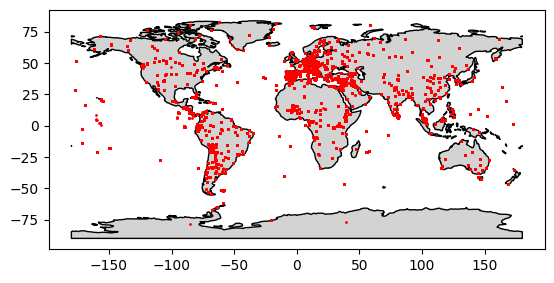

In [13]:
plt.figure()
# Plot World Map with Sample Locations
world = gpd.read_file(gds.get_path('naturalearth.land'))
ax = world.plot(color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, marker='o', color='red', markersize=1, label='Sample Locations')
plt.show()
plt.close();

# Estimating Sample locations to test the model

In [14]:
pickedPointsDict = dict(
    lowData = Point(100, 50),
    highData = Point(7.6, 47.5),
    desertData = Point(-1.97, 25.75),
    northernData = Point(-107.20, 72.25),
    southernData = Point(-67.422, -20.1357)
)
tempDict = {}
for key, point in pickedPointsDict.items():
    tempDict[key] = gdf.loc[gdf.distance(point).idxmin(), 'geometry']

C:\Users\jaxton.gray\AppData\Local\Temp\ipykernel_25648\2725191253.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tempDict[key] = gdf.loc[gdf.distance(point).idxmin(), 'geometry']
C:\Users\jaxton.gray\AppData\Local\Temp\ipykernel_25648\2725191253.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tempDict[key] = gdf.loc[gdf.distance(point).idxmin(), 'geometry']
C:\Users\jaxton.gray\AppData\Local\Temp\ipykernel_25648\2725191253.py:10: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  tempDict[key] = gdf.loc[gdf.distance(point).idxmin(), 'geometry']
C:\Users\jaxton.gra

In [15]:
tempDict

{'lowData': <POINT (104.283 52.3)>,
 'highData': <POINT (7.584 47.543)>,
 'desertData': <POINT (-2.17 30.13)>,
 'northernData': <POINT (-105.117 69.1)>,
 'southernData': <POINT (-67.669 -19.65)>}

<Figure size 640x480 with 0 Axes>

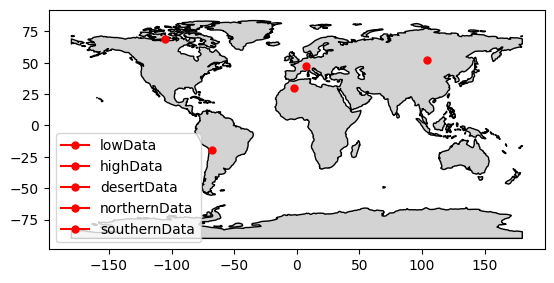

In [16]:
# Plot the Data
plt.figure()
world.plot(color='lightgrey', edgecolor='black')
for key, point in tempDict.items():
    plt.plot(point.x, point.y, marker='o', color='red', markersize=5, label=key)
plt.legend()
plt.show()
plt.close()

<Figure size 640x480 with 0 Axes>

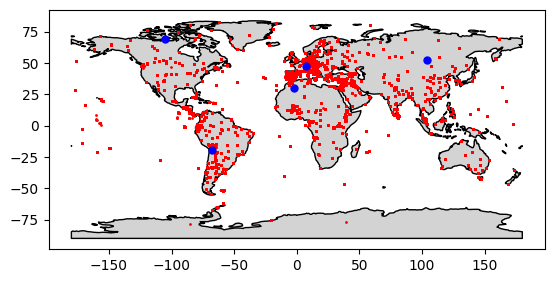

In [17]:
# Plot both the picked points, world map, and the sample locations
plt.figure()
ax = world.plot(color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, marker='o', color='red', markersize=1, label='Sample Locations')
for key, point in tempDict.items():
    plt.plot(point.x, point.y, marker='o', color='blue', markersize=5, label=f'{key} Point')
plt.show()


# Breaking down the picked points

In [18]:
# Count number of samples per location
sample_counts = gdf.groupby(['Lat', 'Lon']).size().reset_index(name='Sample Count')
sample_counts

,Lat,Lon,Sample Count
0,-78.583331,-85.416667,1
1,-77.190000,39.420000,1
2,-75.583333,-20.566667,599
3,-75.580000,-20.570000,1
4,-67.570000,-68.130000,261
...,...,...,...
1354,78.916667,11.933333,374
1355,80.000000,-85.560000,56
1356,80.616667,58.050000,11
1357,81.600000,-16.670000,94


In [19]:
# All points that match the picked points
gdf[gdf.intersects(tempDict['lowData'])]

Symbol,Lat,Lon,Alt,Date,H2,O18,geometry
92173,52.3,104.283333,469.0,2011-06-14 22:00:00+00:00,-111.2,-14.0,POINT (104.28333 52.3)
92174,52.3,104.283333,469.0,2011-07-14 22:00:00+00:00,-74.1,-9.7,POINT (104.28333 52.3)
92175,52.3,104.283333,469.0,2011-08-14 22:00:00+00:00,-101.4,-14.2,POINT (104.28333 52.3)
92176,52.3,104.283333,469.0,2011-09-14 22:00:00+00:00,-108.0,-13.1,POINT (104.28333 52.3)
92177,52.3,104.283333,469.0,2011-10-14 22:00:00+00:00,-127.0,-17.3,POINT (104.28333 52.3)
92178,52.3,104.283333,469.0,2011-11-14 23:00:00+00:00,-224.1,-30.1,POINT (104.28333 52.3)
92179,52.3,104.283333,469.0,2011-12-14 23:00:00+00:00,-208.7,-27.3,POINT (104.28333 52.3)
92180,52.3,104.283333,469.0,2012-01-14 23:00:00+00:00,-218.7,-29.0,POINT (104.28333 52.3)
92181,52.3,104.283333,469.0,2012-02-14 23:00:00+00:00,-207.4,-26.4,POINT (104.28333 52.3)
92182,52.3,104.283333,469.0,2012-06-14 22:00:00+00:00,-91.8,-10.0,POINT (104.28333 52.3)


In [20]:
# Number of data in each picked point
total = 0
for key, point in tempDict.items():
    count = gdf[gdf.intersects(point)].shape[0]
    total += count
    print(f"{key}: {count} samples")

lowData: 55 samples
highData: 237 samples
desertData: 10 samples
northernData: 58 samples
southernData: 15 samples


In [21]:
total/len(gdf) * 100

0.3655469557249527

# Exploring the Years

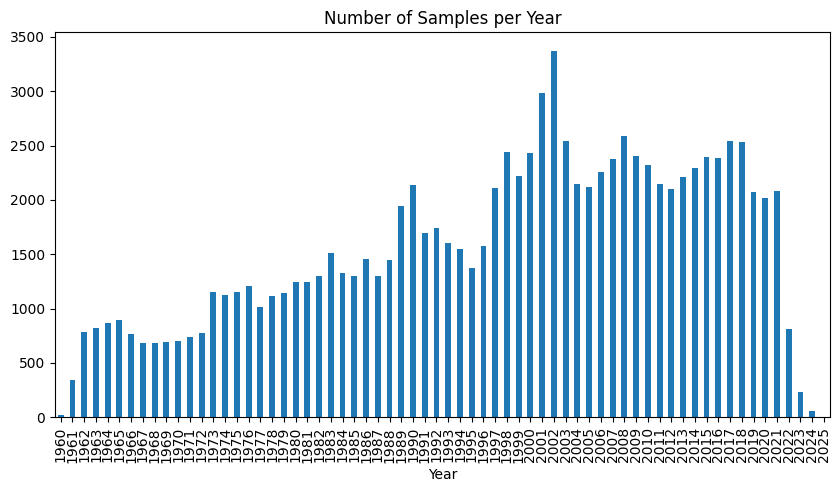

In [22]:
# Plot the number of samples per year
gdf['Year'] = gdf['Date'].dt.year
gdf['Year'].value_counts().sort_index().plot(kind='bar', figsize=(10, 5))
plt.title('Number of Samples per Year');

In [23]:
import seaborn as sns

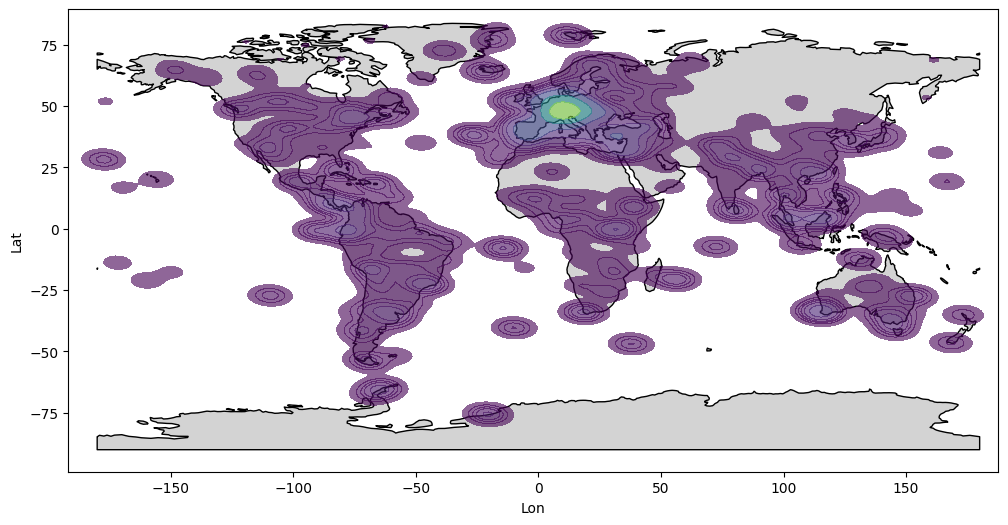

C:\Users\jaxton.gray\AppData\Local\Temp\ipykernel_25648\2938455235.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


Text(0.5, 1.0, 'Sample Location Density')

In [24]:
# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))
world.plot(ax=ax, color='lightgrey', edgecolor='black')
sns.kdeplot(data=gdf, x='Lon', y='Lat', ax=ax, cmap='viridis', fill=True, bw_adjust=0.5, alpha=0.6)
plt.show()
ax.legend()
ax.set_title('Sample Location Density')
